# Intel Image Classification
 After trying out the cifar10 dataset,we will train a CNN model using another publically available dataset, that is ,Intel Image Classification.
 it contains images of :
  * buildings
  * forest
  * glacier
  * mountain
  * sea
  * street

# Importing neccesary libraries

In [225]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout,Conv2D,MaxPooling2D,Rescaling,BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

import data from dataset, train test and validation
-

In [226]:
train=tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    subset='training',
    validation_split=0.2,
    image_size=(150,150),
    batch_size=32,
    seed=42)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [227]:
test=tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test",
    image_size=(150,150),
    batch_size=32, 
    seed=42)

Found 3000 files belonging to 6 classes.


In [228]:
validation=tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    subset='validation',
    validation_split=0.2,
    image_size=(150,150),
     batch_size=32,
    seed=42
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [229]:
print(train.class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


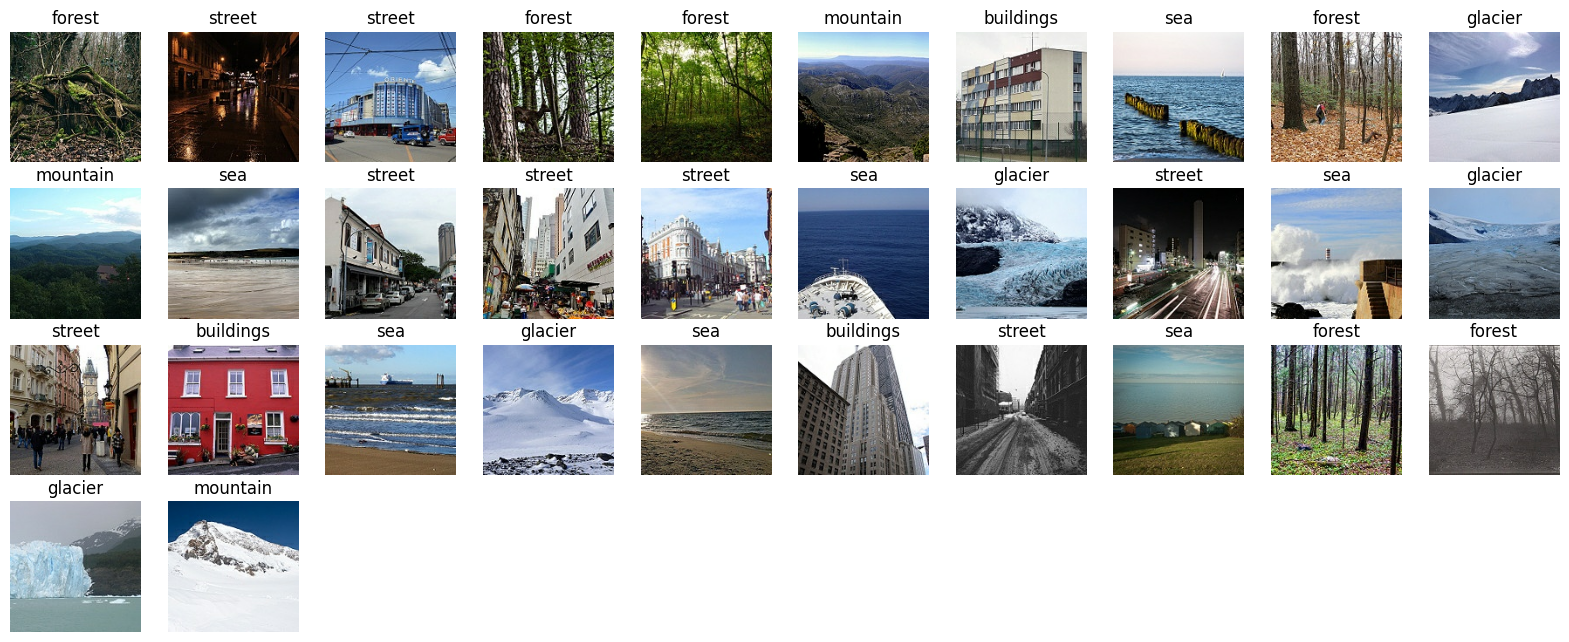

In [230]:
plt.figure(figsize=(20,20))

for images,labels in train.take(1):
    for i in range (32):
        plt.subplot(10,10,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train.class_names[labels[i]])
        plt.axis('off')
plt.show()


 data is labeled and showed correctly, so data is accurate
 -

# Building Model 

Building Model Architecture
-

In [231]:
base_model = Sequential([
    tf.keras.Input(shape=(150,150,3)),
    Rescaling(1./255),

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        activation='relu',
        padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.3),                 
   
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding='same',
        activation='relu',
        strides=(1,1)),
   MaxPooling2D((2,2)),
     Dropout(0.3),
    
  Conv2D(
      filters=128,
      kernel_size=(3,3),
      activation='relu',
      strides=(1,1),
      padding='same'),
    MaxPooling2D((2,2)),
     Dropout(0.3),

   Flatten(),
   Dense(128,activation='relu'),
   Dropout(0.3), 
   Dense(64,activation='relu'),
   Dropout(0.3),
   Dense(6,activation='softmax')

],name='Intel_CNN_Classification')

In [232]:
base_model.summary()

Model: "Intel_CNN_Classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_11 (Rescaling)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,410,438 (20.64 MB)

 Trainable params: 5,410,438 (20.64 MB)

 Non-trainable params: 0 (0.00 B)

Good amount of parameters
-

Compiling model with cateogrical crossentropy, adam optimizer and accuracy metric
-

In [233]:
base_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

Added EarlyStopping to avoid Overfitting
-

In [234]:
early_stop=EarlyStopping(
    patience=3,
    monitor='val_loss',
    restore_best_weights=True,
) 

Finally,training the model
-

In [235]:
base_history= base_model.fit(
    train,
    validation_data=validation,
    epochs=100,
    callbacks=[early_stop])

Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.4800 - loss: 1.2913 - val_accuracy: 0.5563 - val_loss: 1.1031
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6234 - loss: 0.9775 - val_accuracy: 0.6939 - val_loss: 0.8296
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7006 - loss: 0.8124 - val_accuracy: 0.7680 - val_loss: 0.6762
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7528 - loss: 0.7032 - val_accuracy: 0.7880 - val_loss: 0.6185
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.7818 - loss: 0.6218 - val_accuracy: 0.8011 - val_loss: 0.5585
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8057 - loss: 0.5517 - val_accuracy: 0.8001 - val_loss: 0.5590
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8281 - loss: 0.4981 - val_accuracy: 0.8022 - val_loss: 0.5639
Epoch 8/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8416 - loss: 0

In [256]:
base_test_loss,base_test_accuracy=base_model.evaluate(test)
print("test loss:",base_test_loss)
print("test_accuracy:",base_test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8157 - loss: 0.5397
test loss: 0.5397096872329712
test_accuracy: 0.815666675567627


**81% test Accuracy is good with 0.53 loss, but we can reduce it if we normalize each batch output before it goes to next Convolutional layer**


# Retraining with Normalization

Recreating Batch Normalized Architecture
-

In [242]:
Batch_Normalized_model = Sequential([
    tf.keras.Input(shape=(150,150,3)),
    Rescaling(1./255),

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        activation='relu',
        padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),                 
   
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding='same',
        activation='relu',
        strides=(1,1)),
    BatchNormalization(),
   MaxPooling2D((2,2)),
     Dropout(0.3),
    
  Conv2D(
      filters=128,
      kernel_size=(3,3),
      activation='relu',
      strides=(1,1),
      padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
     Dropout(0.3),

   Flatten(),
   Dense(128,activation='relu'),
   Dropout(0.3), 
   Dense(64,activation='relu'),
   Dropout(0.3),
   Dense(6,activation='softmax')

],name='Intel_CNN_Classification_batch_normalized')

In [243]:
Batch_Normalized_model.summary()

Model: "Intel_CNN_Classification_batch_normalized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_13 (Rescaling)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,411,334 (20.64 MB)

 Trainable params: 5,410,886 (20.64 MB)

 Non-trainable params: 448 (1.75 KB)

New parameters because of BN
-

Compiling model, same as base model
-

In [244]:
Batch_Normalized_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

Earlystopping for overfitting

In [253]:
Batch_Normalized_early_stop=EarlyStopping(
    patience=3,
    monitor='val_loss',
    restore_best_weights=True
)

In [254]:
Batch_Normalized_history= Batch_Normalized_model.fit(
    train,
    validation_data=validation,
    epochs=100,
    callbacks=[Batch_Normalized_early_stop])

Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.2712 - loss: 1.6785 - val_accuracy: 0.2259 - val_loss: 4.6990
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.2862 - loss: 1.5922 - val_accuracy: 0.3179 - val_loss: 1.4943
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.3055 - loss: 1.5357 - val_accuracy: 0.3204 - val_loss: 1.9358
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.3469 - loss: 1.4521 - val_accuracy: 0.4715 - val_loss: 1.2208
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4141 - loss: 1.3324 - val_accuracy: 0.4694 - val_loss: 1.2196
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4389 - loss: 1.2576 - val_accuracy: 0.5189 - val_loss: 1.1029
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4635 - loss: 1.2143 - val_accuracy: 0.5078 - val_loss: 1.1886
Epoch 8/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4796 - loss: 1

In [255]:
bn_test_loss,bn_test_accuracy=Batch_Normalized_model.evaluate(test)
print("test loss:",bn_test_loss)
print("test_accuracy:",bn_test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5370 - loss: 1.0023
test loss: 1.0022677183151245
test_accuracy: 0.5370000004768372


## Batch Normalization Model Evaluation

The Batch Normalization model achieved a **test accuracy of 53.70%** with a **test loss of 1.0023**.

Compared to the Base CNN (**81.56%** accuracy), the Batch Normalization model performed worse on this dataset. Therefore, the **Base CNN** was selected as the final model.

In [257]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["test Accuracy", "test Loss"],
    "Base CNN": [base_test_accuracy, base_test_loss],
    "Batch Normalization CNN": [bn_test_accuracy, bn_test_loss]})
print(comparison)

          Metric  Base CNN  Batch Normalization CNN
0  test Accuracy  0.815667                 0.537000
1      test Loss  0.539710                 1.002268


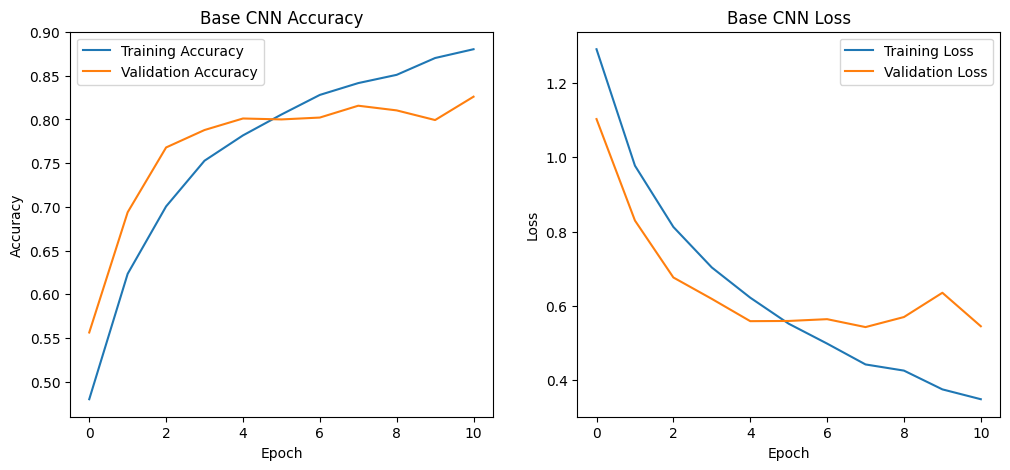

In [258]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(base_history.history['accuracy'], label='Training Accuracy')
plt.plot(base_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Base CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(base_history.history['loss'], label='Training Loss')
plt.plot(base_history.history['val_loss'], label='Validation Loss')
plt.title("Base CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# training summary

* Training accuracy increased from **48%** to **88%**.
* Validation accuracy improved from **56%** to **83%**.
* Training loss decreased from **1.30** to **0.35**.
* Validation loss decreased from **1.10** to **0.55**.
* Both accuracy and loss curves show that the model learned well.
* A small gap between training and validation curves indicates only **slight overfitting**.
* Overall, the Base CNN performed well and achieved a **test accuracy of 81.56%**.

In [262]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
class_names = train.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [264]:
y_test = []
y_pred = []

for images, labels in test:
    predictions = base_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_test.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_test = np.array(y_test)
y_pred = np.array(y_pred)

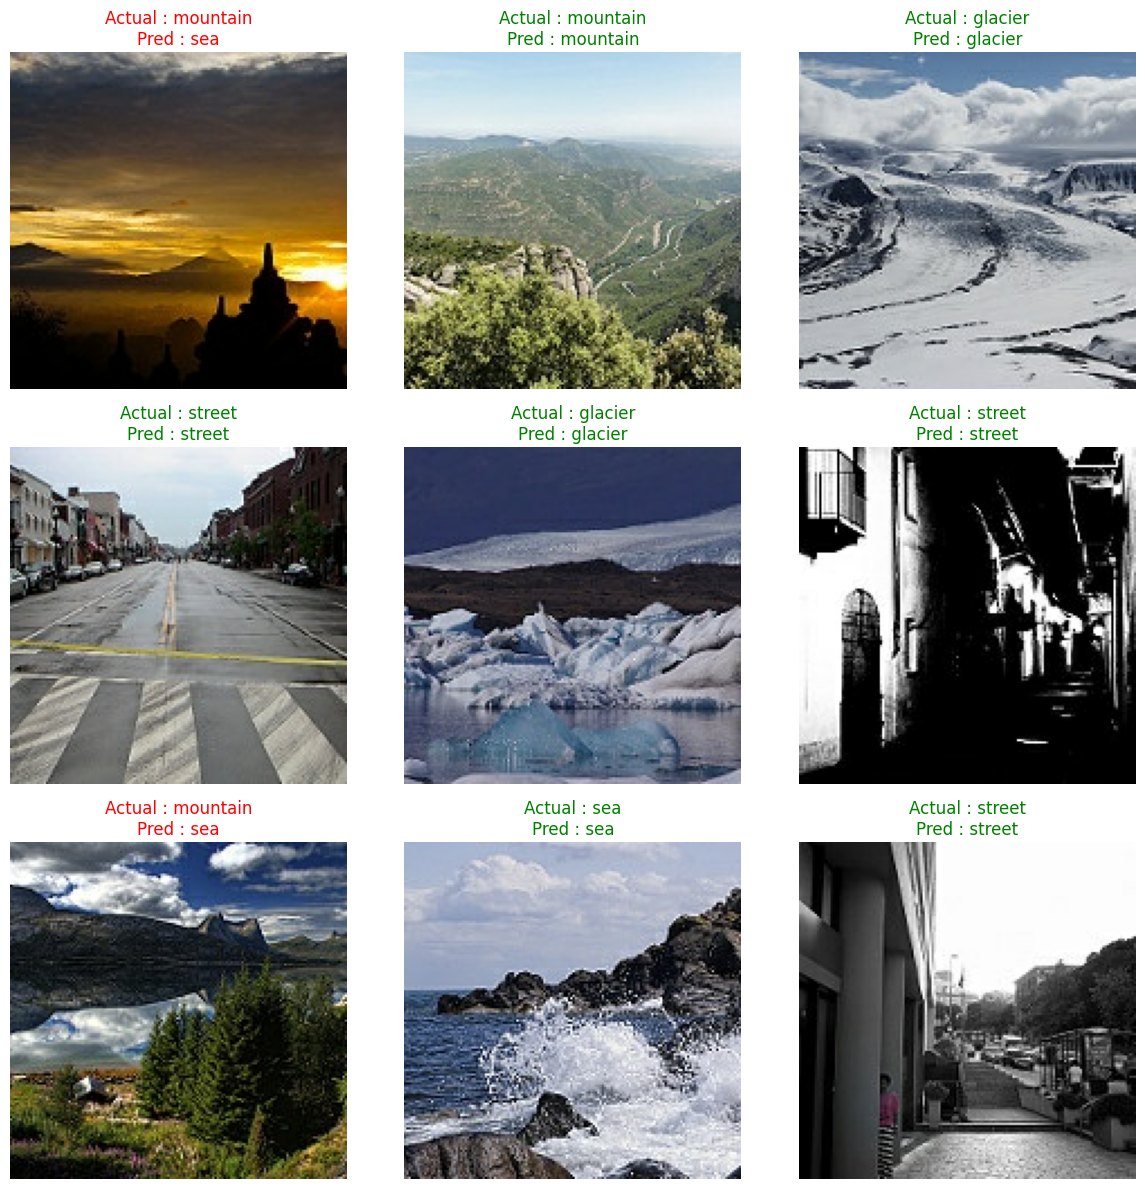

In [270]:
plt.figure(figsize=(12,12))

for images, labels in test.take(1):
    predictions = base_model.predict(images, verbose=0)
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        actual = class_names[labels[i]]
        predicted = class_names[np.argmax(predictions[i])]
        color = "green" if actual == predicted else "red"
        plt.title(f"Actual : {actual}\nPred : {predicted}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()

## Sample Predictions

The images above show the model's predictions on test data.

- Green labels indicate correct predictions.
- Red labels indicate incorrect predictions.

The model correctly classified **7 out of 9** images. The incorrect predictions are between **mountain** and **sea**, as these scenes have similar visual features in some images.

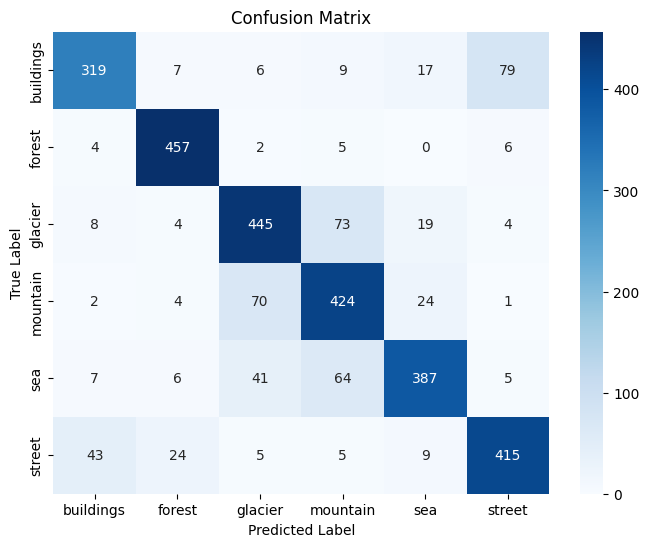

In [267]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(  cm, annot=True,fmt="d",  cmap="Blues",xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix

The model correctly classified **319 buildings**, **457 forests**, **445 glaciers**, **424 mountains**, **387 seas**, and **415 streets**.

Most misclassifications occurred between **glacier and mountain** (73 & 70 images), followed by **sea and mountain** (64 images). This shows the model performs well overall but finds these visually similar classes more challenging.

In [271]:
from sklearn.metrics import classification_report
print(classification_report( y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.83      0.73      0.78       437
      forest       0.91      0.96      0.94       474
     glacier       0.78      0.80      0.79       553
    mountain       0.73      0.81      0.77       525
         sea       0.85      0.76      0.80       510
      street       0.81      0.83      0.82       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



## Classification Report

The model achieved an overall **accuracy of 82%** on the test dataset.

- **Forest** performed the best with **91% precision**, **96% recall**, and **94% F1-score**.
- **Street** and **Sea** also achieved good performance with **82%** and **80% F1-score**, respectively.
- **Buildings**, **Glacier**, and **Mountain** achieved F1-scores between **77% and 79%**.
- The lower scores for **Glacier** and **Mountain** are due to their similar visual features, leading to some misclassifications.

Overall, the model shows balanced performance across all six classes.

# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to classify images from the Intel Image Classification dataset into six scene categories: Buildings, Forest, Glacier, Mountain, Sea, and Street.

Two models were evaluated: a Base CNN and a CNN with Batch Normalization. The Base CNN achieved a **test accuracy of 81.56%**, while the Batch Normalization model achieved **53.70%**. Based on the evaluation results, the Base CNN performed better and was selected as the final model.

The confusion matrix and classification report showed that the model classified most images correctly, with a few misclassifications between visually similar classes such as glacier, mountain, and sea.

Overall, the project demonstrates that a simple CNN can effectively classify natural scene images with good accuracy and generalize well to unseen data.

## Save the Trained Model

After training and evaluating the Base CNN model, it is saved in the `.keras` format. Saving the model allows it to be reused later for making predictions without retraining.

In [272]:
base_model.save("intel_cnn_model.keras")